In [1]:
%pip install 'qbraid[visualization]' -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from qbraid import QbraidProvider
from qbraid.visualization import plot_histogram, plot_distribution

provider = QbraidProvider()
provider.save_config(overwrite=True)

In [8]:
devices = provider.get_devices()

print(f"{'Device ID':<15} {'Status':<10}")
print("-" * 25)

for device in devices:
    print(f"{device.id:<15} {device.status().name:<10}")

Device ID       Status    
-------------------------
aws:aws:sim:dm1 ONLINE    
qbraid:nec:sim:vector-annealer OFFLINE   
azure:rigetti:qpu:ankaa-3 ONLINE    
azure:pasqal:sim:emu-tn ONLINE    
aws:iqm:qpu:emerald OFFLINE   
azure:ionq:qpu:forte-1 OFFLINE   
qbraid:qbraid:sim:qir-sv ONLINE    
azure:quantinuum:sim:h2-1sc ONLINE    
aws:aws:sim:tn1 ONLINE    
azure:rigetti:qpu:cepheus-1-36q ONLINE    
azure:ionq:sim:simulator ONLINE    
aws:aqt:qpu:ibex-q1 UNAVAILABLE
aws:quera:qpu:aquila ONLINE    
aws:ionq:qpu:aria-1 OFFLINE   
azure:quantinuum:sim:h2-1e ONLINE    
azure:pasqal:qpu:fresnel OFFLINE   
aws:ionq:qpu:forte-1 OFFLINE   
aws:iqm:qpu:garnet ONLINE    
azure:ionq:qpu:aria-1 OFFLINE   
aws:rigetti:qpu:ankaa-3 ONLINE    
aws:aws:sim:sv1 ONLINE    
aws:ionq:qpu:forte-enterprise-1 ONLINE    
azure:rigetti:sim:qvm ONLINE    
azure:ionq:qpu:forte-enterprise-1 OFFLINE   


In [9]:
device = provider.get_device("azure:ionq:sim:simulator")

In [10]:
device.num_qubits

29

In [11]:
device.profile.noise_models

In [12]:
# GHZ state as an OpenQASM 2 string.
# Note: no measurement gates are included.

qasm_ghz = """
OPENQASM 2;
include "qelib1.inc";
qreg q[3];

h q[0];
cx q[0], q[1];
cx q[1], q[2];
"""

In [13]:
job = device.run(qasm_ghz, shots=1000)

In [14]:
job.status()

<QUEUED: 'job is queued'>

In [15]:
job.wait_for_final_state()

result = job.result()

result.details

{'time_stamps': TimeStamps(createdAt=datetime.datetime(2026, 2, 27, 23, 3, 47, 253000, tzinfo=datetime.timezone.utc), endedAt=datetime.datetime(2026, 2, 27, 23, 3, 51, 270000, tzinfo=datetime.timezone.utc), executionDuration=0),
 'cost': Credits('0')}

In [16]:
counts = result.data.measurement_counts
probabilities = result.data.get_probabilities()

print(f"Measurement Counts: {counts}")
print(f"Probabilities: {probabilities}")

Measurement Counts: {'000': 500, '111': 500}
Probabilities: {'000': 0.5, '111': 0.5}


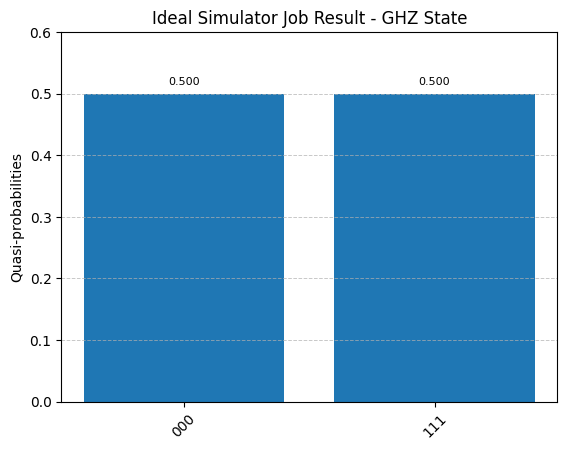

In [17]:
plot_distribution(counts, title="Ideal Simulator Job Result - GHZ State")

In [18]:
# OpenQASM 2 string with IonQ native gates

qasm_ionq_native = """
OPENQASM 2;
include "qelib1.inc";
qreg q[3];

gpi(0.5) q[0];
gpi2(0.5) q[1];
ms(0, 0.5, 0.25) q[1], q[2];
"""

In [20]:
job = device.run(qasm_ionq_native, shots=1000, runtime_options={"noise": {"model": "aria-1", "seed": 42}})

In [14]:
job.wait_for_final_state()

result = job.result()

In [15]:
counts = {int(k, 2): v for k, v in result.data.measurement_counts.items()}

print(f"Counts: {counts}")

Counts: {0: 1, 1: 262, 3: 259, 5: 235, 7: 243}


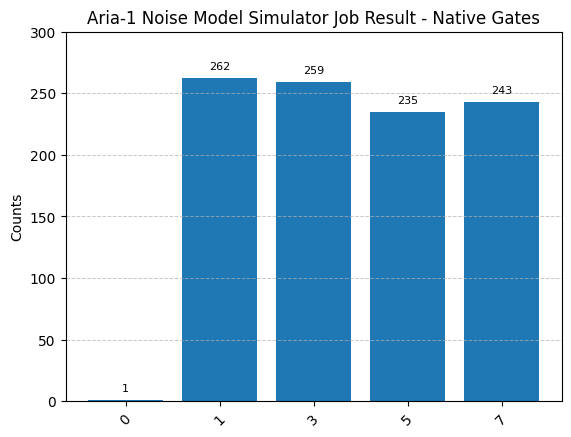

In [16]:
plot_histogram(counts, title="Aria-1 Noise Model Simulator Job Result - Native Gates")